# Day 3 — Computer Vision Preprocessing with OpenCV
## Melanoma Skin Cancer Dataset — Benign vs Malignant

### Learning Objectives
By the end of this notebook, we will:
- Read and inspect skin-lesion images using OpenCV.
- Resize images to a fixed input size.
- Understand and fix the BGR vs RGB issue.
- Normalize pixel values when appropriate.
- Build a reusable OpenCV preprocessing function.
- Build an image augmentation pipeline.
- Visualize several augmented versions of one image.
- Apply Canny edge detection as a classical computer-vision example.
- Understand model-specific preprocessing for transfer learning.
- Prepare the preprocessing pipeline for a pretrained model such as ResNet50.

##  Dataset

We use the Kaggle dataset:

**Melanoma Skin Cancer Dataset - Benign vs Malignant**

The dataset contains two image classes: **benign** and **malignant**. The notebook is written to work with a typical `train/` and `test/` folder structure and automatically detect the class folders.

Dataset:
- Kaggle: `https://www.kaggle.com/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/code`



##  Import Libraries

We install/import the libraries needed for image processing, augmentation, visualization, and dataset handling.

In [1]:
!pip -q install kagglehub opencv-python

import os
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)

TensorFlow version: 2.20.0
OpenCV version: 5.0.0


##  Download the Kaggle Dataset


In [2]:
import kagglehub

DATASET_HANDLE = "ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant"

try:
    dataset_root = Path(kagglehub.dataset_download(DATASET_HANDLE))
    print("Dataset downloaded to:")
    print(dataset_root)
except Exception as e:
    print("KaggleHub could not download the dataset automatically.")
    print("Error:", e)
    print("\nIf needed, download the dataset from Kaggle and upload/extract it into /content.")
    dataset_root = Path("/content")

100%|██████████| 79.4M/79.4M [00:00<00:00, 255MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1


##  Inspect the Dataset Structure

We inspect the folders to identify train, test, and the class directories.

In [3]:
def print_tree(root, max_depth=3):
    root = Path(root)
    print(f"Root: {root}")
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth <= max_depth:
            prefix = "    " * (depth - 1)
            marker = "📁" if path.is_dir() else "📄"
            print(f"{prefix}{marker} {path.name}")

print_tree(dataset_root, max_depth=3)

Streaming output truncated to the last 5000 lines.
        📄 1530.jpg
        📄 1531.jpg
        📄 1532.jpg
        📄 1533.jpg
        📄 1534.jpg
        📄 1535.jpg
        📄 1536.jpg
        📄 1537.jpg
        📄 1538.jpg
        📄 1539.jpg
        📄 154.jpg
        📄 1540.jpg
        📄 1541.jpg
        📄 1542.jpg
        📄 1543.jpg
        📄 1544.jpg
        📄 1545.jpg
        📄 1546.jpg
        📄 1547.jpg
        📄 1548.jpg
        📄 1549.jpg
        📄 155.jpg
        📄 1550.jpg
        📄 1551.jpg
        📄 1552.jpg
        📄 1553.jpg
        📄 1554.jpg
        📄 1555.jpg
        📄 1556.jpg
        📄 1557.jpg
        📄 1558.jpg
        📄 1559.jpg
        📄 156.jpg
        📄 1560.jpg
        📄 1561.jpg
        📄 1562.jpg
        📄 1563.jpg
        📄 1564.jpg
        📄 1565.jpg
        📄 1566.jpg
        📄 1567.jpg
        📄 1568.jpg
        📄 1569.jpg
        📄 157.jpg
        📄 1570.jpg
        📄 1571.jpg
        📄 1572.jpg
        📄 1573.jpg
        📄 1574.jpg
        📄 1575.jpg
   

##  Locate Train and Test Folders




In [4]:
def find_dir(root, names):
    names = {n.lower() for n in names}
    candidates = [p for p in Path(root).rglob("*") if p.is_dir() and p.name.lower() in names]
    return candidates[0] if candidates else None

TRAIN_DIR = find_dir(dataset_root, {"train", "training"})
TEST_DIR = find_dir(dataset_root, {"test", "testing"})

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)

if TRAIN_DIR is None:
    raise FileNotFoundError(
        "Training folder was not found. Check the dataset tree above and set TRAIN_DIR manually."
    )

TRAIN_DIR: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/train
TEST_DIR : /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test


##  Check Class Folders

The expected structure is approximately:

```text
train/
├── benign/
└── malignant/

test/
├── benign/
└── malignant/
```

The code below detects the class folders automatically.

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_class_dirs(split_dir):
    split_dir = Path(split_dir)
    return sorted([p for p in split_dir.iterdir() if p.is_dir()])

train_class_dirs = get_class_dirs(TRAIN_DIR)

print("Training classes:")
for p in train_class_dirs:
    count = sum(1 for f in p.rglob("*") if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS)
    print(f"- {p.name}: {count} images")

if TEST_DIR is not None:
    print("\nTest classes:")
    for p in get_class_dirs(TEST_DIR):
        count = sum(1 for f in p.rglob("*") if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS)
        print(f"- {p.name}: {count} images")

Training classes:
- Benign: 6289 images
- Malignant: 5590 images

Test classes:
- Benign: 1000 images
- Malignant: 1000 images


##  Visualize One Image From Each Class

Before preprocessing, it is useful to inspect the original images.

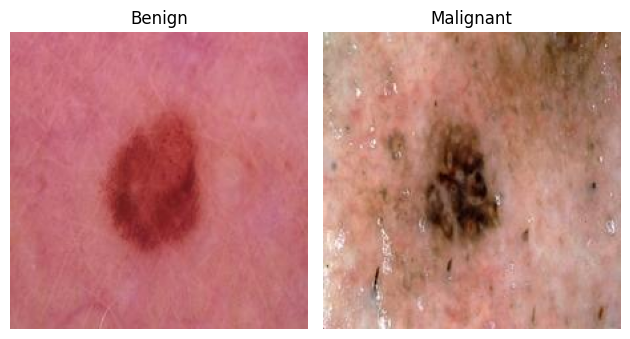

In [6]:
def collect_images(split_dir):
    data = []
    split_dir = Path(split_dir)
    for class_dir in get_class_dirs(split_dir):
        for f in class_dir.rglob("*"):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS:
                data.append((f, class_dir.name))
    return data

train_images = collect_images(TRAIN_DIR)

class_to_sample = {}
for path, label in train_images:
    class_to_sample.setdefault(label, path)


for i, (label, path) in enumerate(class_to_sample.items()):
    img_bgr = cv2.imread(str(path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(class_to_sample), i + 1)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

##  Inspect Image Dimensions

Real image datasets can contain images with different dimensions. A model normally expects a consistent input shape.

We inspect several images using OpenCV.

In [7]:
sample_items = random.sample(train_images, min(10, len(train_images)))
for path, label in sample_items:
    img = cv2.imread(str(path))
    print(f"{path.name:35s} | class={label:10s} | shape={img.shape}")

4508.jpg                            | class=Benign     | shape=(224, 224, 3)
1308.jpg                            | class=Benign     | shape=(224, 224, 3)
1085.jpg                            | class=Benign     | shape=(224, 224, 3)
2295.jpg                            | class=Benign     | shape=(224, 224, 3)
1661.jpg                            | class=Malignant  | shape=(224, 224, 3)
1307.jpg                            | class=Benign     | shape=(224, 224, 3)
917.jpg                             | class=Malignant  | shape=(224, 224, 3)
3013.jpg                            | class=Malignant  | shape=(224, 224, 3)
4482.jpg                            | class=Benign     | shape=(224, 224, 3)
1551.jpg                            | class=Malignant  | shape=(224, 224, 3)


##  OpenCV: Read an Image

cv2.imread() reads an image and returns a NumPy array.

OpenCV normally reads color images in **BGR** order rather than RGB.

In [8]:
sample_path = train_images[0][0]
img_bgr = cv2.imread(str(sample_path))
print("Image path:", sample_path)
print("Shape:", img_bgr.shape)
print("Data type:", img_bgr.dtype)
print("Pixel range:", img_bgr.min(), "to", img_bgr.max())

Image path: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/train/Benign/721.jpg
Shape: (224, 224, 3)
Data type: uint8
Pixel range: 23 to 235


##  BGR vs RGB — The Classic OpenCV Pitfall

OpenCV reads:

**B → G → R**

Most visualization libraries and common deep-learning workflows use:

**R → G → B**

Therefore, we convert:

BGR → RGB

using cv2.cvtColor().

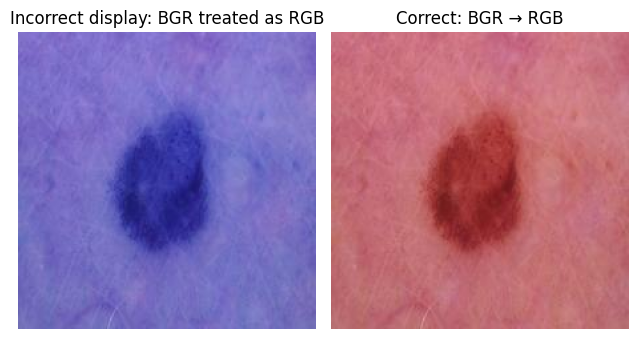

In [9]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.subplot(1, 2, 1)
plt.imshow(img_bgr)
plt.title("Incorrect display: BGR treated as RGB")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.title("Correct: BGR → RGB")
plt.axis("off")
plt.tight_layout()
plt.show()

## Resize the Image

For this notebook we use **224 × 224** because this is a common input size for pretrained image-classification models such as ResNet50 and MobileNetV2.

OpenCV's resize syntax is:

cv2.resize(image, (width, height))


Original shape: (224, 224, 3)
Resized shape : (224, 224, 3)


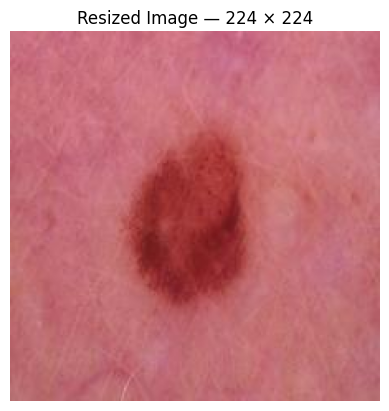

In [10]:
TARGET_SIZE = (224, 224)
img_resized = cv2.resize(img_rgb, TARGET_SIZE)
print("Original shape:", img_rgb.shape)
print("Resized shape :", img_resized.shape)
plt.imshow(img_resized)
plt.title("Resized Image — 224 × 224")
plt.axis("off")
plt.show()

##  Normalize Pixel Values

Original uint8 images usually contain pixel values from **0 to 255**.

A simple normalization is:

`pixel / 255.0`

which maps the values approximately to **0–1**.

> `/255.0` is a general normalization example. When using a pretrained model, we should follow that model's official preprocessing function instead of assuming `/255.0` is always correct.

In [11]:
img_normalized = img_resized.astype(np.float32) / 255.0
print("Data type:", img_normalized.dtype)
print("Minimum:", img_normalized.min())
print("Maximum:", img_normalized.max())

Data type: float32
Minimum: 0.09019608
Maximum: 0.92156863


##  Build a Complete OpenCV Preprocessing Function

This function performs the main Day 3 preprocessing steps:
1. Read the image.
2. Resize it.
3. Convert BGR to RGB.
4. Normalize pixel values to 0–1.

The function also checks whether OpenCV successfully loaded the image.

In [12]:
def preprocess_image_opencv(image_path, target_size=(224, 224)):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    img = cv2.resize(img, target_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    return img
processed_img = preprocess_image_opencv(sample_path)
print("Processed shape:", processed_img.shape)
print("Processed dtype:", processed_img.dtype)
print("Processed range:", processed_img.min(), "to", processed_img.max())

Processed shape: (224, 224, 3)
Processed dtype: float32
Processed range: 0.09019608 to 0.92156863


##  Before vs After Preprocessing

Resizing changes the image dimensions, while normalization changes the numerical representation of pixel values.

The visual appearance should remain recognizable after these operations.

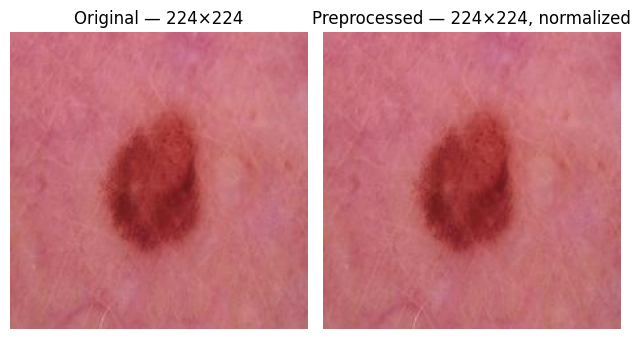

In [13]:
original = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
processed = preprocess_image_opencv(sample_path)
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title(f"Original — {original.shape[1]}×{original.shape[0]}")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Preprocessed — 224×224, normalized")
plt.axis("off")
plt.tight_layout()
plt.show()

##  Data Augmentation

Augmentation creates different versions of training images using random transformations.

For this task we use:
- Rotation
- Zoom
- Horizontal flip
- Brightness changes

These transformations increase training-data diversity and can help reduce overfitting.

**Augmentation should normally be applied to the training data, not randomly to the validation/test data.**

In [14]:
datagen = ImageDataGenerator(rotation_range=20,zoom_range=0.15,horizontal_flip=True,brightness_range=[0.8, 1.2],rescale=1./255)
print("Augmentation pipeline created.")

Augmentation pipeline created.


##  Generate Augmented Versions of One Image

ImageDataGenerator expects a batch dimension:

(batch, height, width, channels)

So we add one dimension using `np.expand_dims()`.

# Read the original image with OpenCV


In [15]:
aug_img = cv2.imread(str(sample_path))
aug_img = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)

# Add batch dimension


In [16]:
aug_img_batch = np.expand_dims(aug_img, axis=0)
generator = datagen.flow(aug_img_batch,batch_size=1,shuffle=False)
augmented_images = [next(generator)[0] for _ in range(6)]
print("Input batch shape:", aug_img_batch.shape)
print("Number of augmented images:", len(augmented_images))

Input batch shape: (1, 224, 224, 3)
Number of augmented images: 6


##  Visualize Several Augmented Images

Each image below is a different random transformation of the same original image.

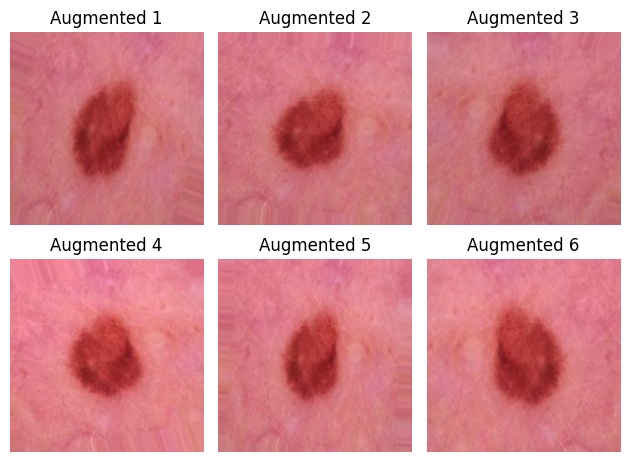

In [17]:
for i, image in enumerate(augmented_images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##  Compare Original and Augmented Image

Augmentation should change the appearance enough to create variation while keeping the class meaning intact.

For skin-lesion classification, augmentation choices should be medically and visually reasonable. Avoid transformations that could create unrealistic training examples.

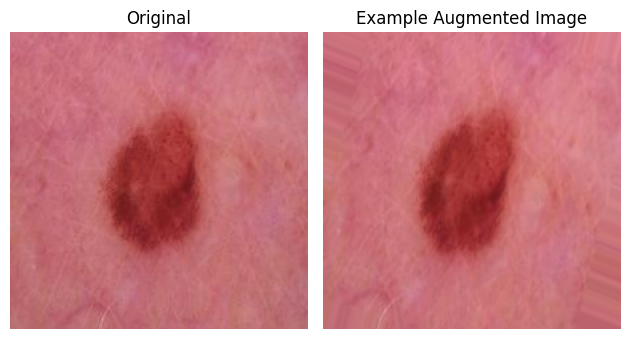

In [18]:
plt.subplot(1, 2, 1)
plt.imshow(aug_img)
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(augmented_images[0])
plt.title("Example Augmented Image")
plt.axis("off")
plt.tight_layout()
plt.show()

##  Canny Edge Detection

Canny edge detection is a classical computer-vision technique that highlights strong boundaries.

It is useful for understanding image-processing fundamentals, although it is **not required as an input step for a typical CNN/transfer-learning classifier**.

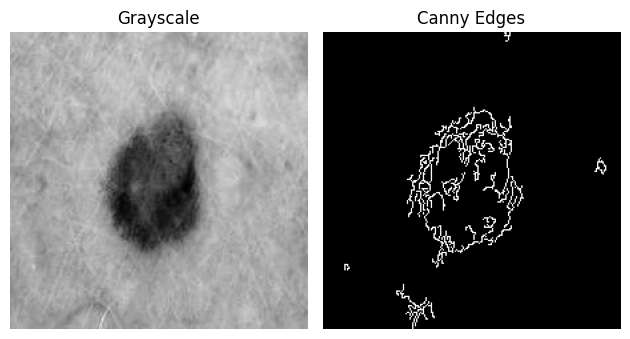

In [36]:
gray = cv2.cvtColor(aug_img, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, 30, 100)
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()


##  Transfer Learning: Why Model-Specific Preprocessing Matters

Pretrained models were trained using a particular image preprocessing convention.
For example, when using a pretrained **ResNet50**, Keras provides:
tensorflow.keras.applications.resnet50.preprocess_input
We should use the preprocessing expected by the chosen pretrained model.
For this section, we demonstrate ResNet50 preprocessing.

# Start from uint8 RGB image


In [20]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input
resnet_img = cv2.imread(str(sample_path))
resnet_img = cv2.cvtColor(resnet_img, cv2.COLOR_BGR2RGB)
resnet_img = cv2.resize(resnet_img, TARGET_SIZE)

# Apply ResNet50-specific preprocessing


In [21]:
resnet_ready = resnet50_preprocess_input(resnet_img.astype(np.float32))
print("Shape:", resnet_ready.shape)
print("Dtype:", resnet_ready.dtype)
print("Minimum:", resnet_ready.min())
print("Maximum:", resnet_ready.max())

Shape: (224, 224, 3)
Dtype: float32
Minimum: -93.779
Maximum: 111.32


##  General Preprocessing Pipeline for Transfer Learning

For a pretrained image classifier, the conceptual pipeline is:

```text
Raw Image
   ↓
OpenCV Read
   ↓
Resize
   ↓
BGR → RGB
   ↓
Training Augmentation (training only)
   ↓
Model-specific preprocess_input
   ↓
Pretrained Model
```

The exact preprocessing order can depend on the framework and model. Always follow the selected model's documentation.

## Prepare the ResNet50 Training, Validation, and Test Pipeline

Because the selected transfer-learning model is ResNet50, the final training, validation, and test pipelines use the preprocessing expected by ResNet50.

Unlike the general `0–1` normalization example shown earlier, ResNet50 preprocessing scales the input according to the ImageNet convention and converts the image values to the distribution expected by the pretrained backbone.

Random augmentation is applied only to the training set. Validation and test images receive no random augmentation; they use only resizing and ResNet50-specific preprocessing.



In [32]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    preprocessing_function=resnet50_preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=SEED
)

validation_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=resnet50_preprocess_input
)

validation_generator = validation_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=SEED
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)



Found 9504 images belonging to 2 classes.
Found 2375 images belonging to 2 classes.
Class indices: {'Benign': 0, 'Malignant': 1}
Training samples: 9504
Validation samples: 2375


## ResNet50 Test Preprocessing

The test set must remain untouched by random augmentation.

It uses only resizing and the same ResNet50-specific preprocessing as the training and validation pipelines, ensuring that all inputs follow the same model-specific convention.



In [33]:
test_datagen = ImageDataGenerator(
    preprocessing_function=resnet50_preprocess_input
)

if TEST_DIR is not None:
    test_generator = test_datagen.flow_from_directory(
        str(TEST_DIR),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    print("Test class indices:", test_generator.class_indices)
    print("Test samples:", test_generator.samples)
else:
    print("No test directory was detected.")


Found 2000 images belonging to 2 classes.
Test class indices: {'Benign': 0, 'Malignant': 1}
Test samples: 2000


## Inspect One ResNet50-Preprocessed Batch

We verify that the pipeline produces the expected tensor shape, data type, and model-specific pixel range.

Because ResNet50 preprocessing is used, the pixel values are not restricted to the range `0–1`.




In [34]:
batch_images, batch_labels = next(train_generator)
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)
print("Image dtype:", batch_images.dtype)
print("Image range:", batch_images.min(), "to", batch_images.max())
print("First labels:", batch_labels[:10])


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Image dtype: float32
Image range: -123.68 to 151.061
First labels: [0. 1. 0. 1. 0. 1. 0. 1. 1. 0.]


## Visualize a Training Batch

The images below come from the training pipeline after resizing, augmentation, and rescaling.

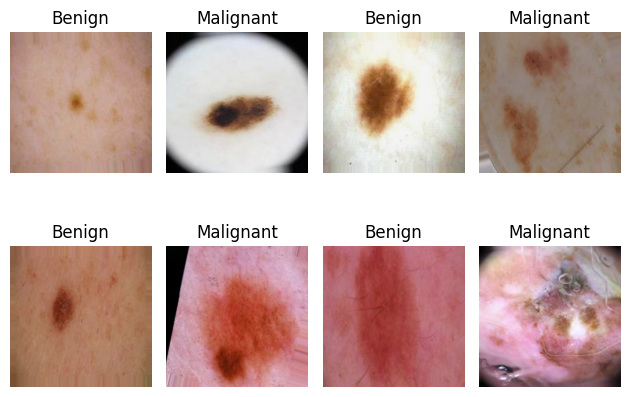

In [35]:
display_images = batch_images.copy()

display_images += np.array(
    [103.939, 116.779, 123.68],
    dtype=np.float32
)

display_images = display_images[..., ::-1]

display_images = np.clip(display_images / 255.0, 0.0, 1.0)

for i in range(min(8, len(display_images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(display_images[i])

    label_name = "Malignant" if batch_labels[i] == 1 else "Benign"
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Preprocessing Verification Checklist

We verify the main Day 3 requirements.

✓ OpenCV image reading

✓ Resize to:", TARGET_SIZE

✓ BGR → RGB conversion

✓ 0–1 normalization example

✓ Reusable OpenCV preprocessing function

✓ Data augmentation pipeline

✓ Augmented image visualization

✓ Canny edge detection demonstration

✓ Model-specific ResNet50 preprocessing example

✓ Training / validation / test pipeline separation

##  Key Observations

### What we learned

1. **Images need standardization** because models require consistent input dimensions and numerical representations.
2. **OpenCV reads color images as BGR**, so we convert them to RGB when required.
3. **Resize** makes image dimensions consistent, such as `224 × 224`.
4. **Normalization** can scale pixel values from `0–255` to `0–1`.
5. **Augmentation** creates varied training examples and can help reduce overfitting.
6. Random augmentation belongs only to the training data. The training and validation pipelines use separate `ImageDataGenerator` objects, while validation and test images receive only resizing and rescaling.
7. **Canny edge detection** is useful for classical computer vision but is not normally required before a CNN.
8. **Transfer-learning models have specific preprocessing expectations**. For the selected ResNet50 model, the pipeline uses `resnet50_preprocess_input` for training, validation, and test images.
9. The training, validation, and test pipelines use the same ResNet50-specific preprocessing convention. Random augmentation is applied only to the training set, while validation and test images remain free of random augmentation.
10. Using the wrong preprocessing can cause a mismatch between the images used during fine-tuning/inference and the distribution used to train the pretrained backbone.



### Final pipeline

Image

 ↓

OpenCV Read

 ↓

Resize

 ↓

BGR → RGB

 ↓

Training Augmentation (training only)

 ↓

Model-specific preprocessing

 ↓

Pretrained CNN


## Conclusion

This notebook completed the Day 3 Computer Vision preprocessing requirements using the melanoma benign-vs-malignant image dataset.

The main outcome is a reusable preprocessing workflow that standardizes images, augments training data, handles OpenCV's BGR format correctly, and prepares the images according to the expectations of a pretrained transfer-learning model.